In [ ]:
import sys

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['omega_b', 'omega_cdm', 'logA', 'h', 'n_s', 'ELG2.b1', 'ELG2.b2', 'ELG2.bs', 'ELG2.auw', 'sigma8_m'][1:-1]

cosmo = AbacusSummit()
truth = {}
for p in params_toplot:
    try:
        truth[p] = cosmo[p]
    except:
        continue
truth['ELG2.auw'] = 1.

def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples

plot_dir = Path('validation_fiber_assignment')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

## AbacusHF mock

Removed no burn in
Removed no burn in


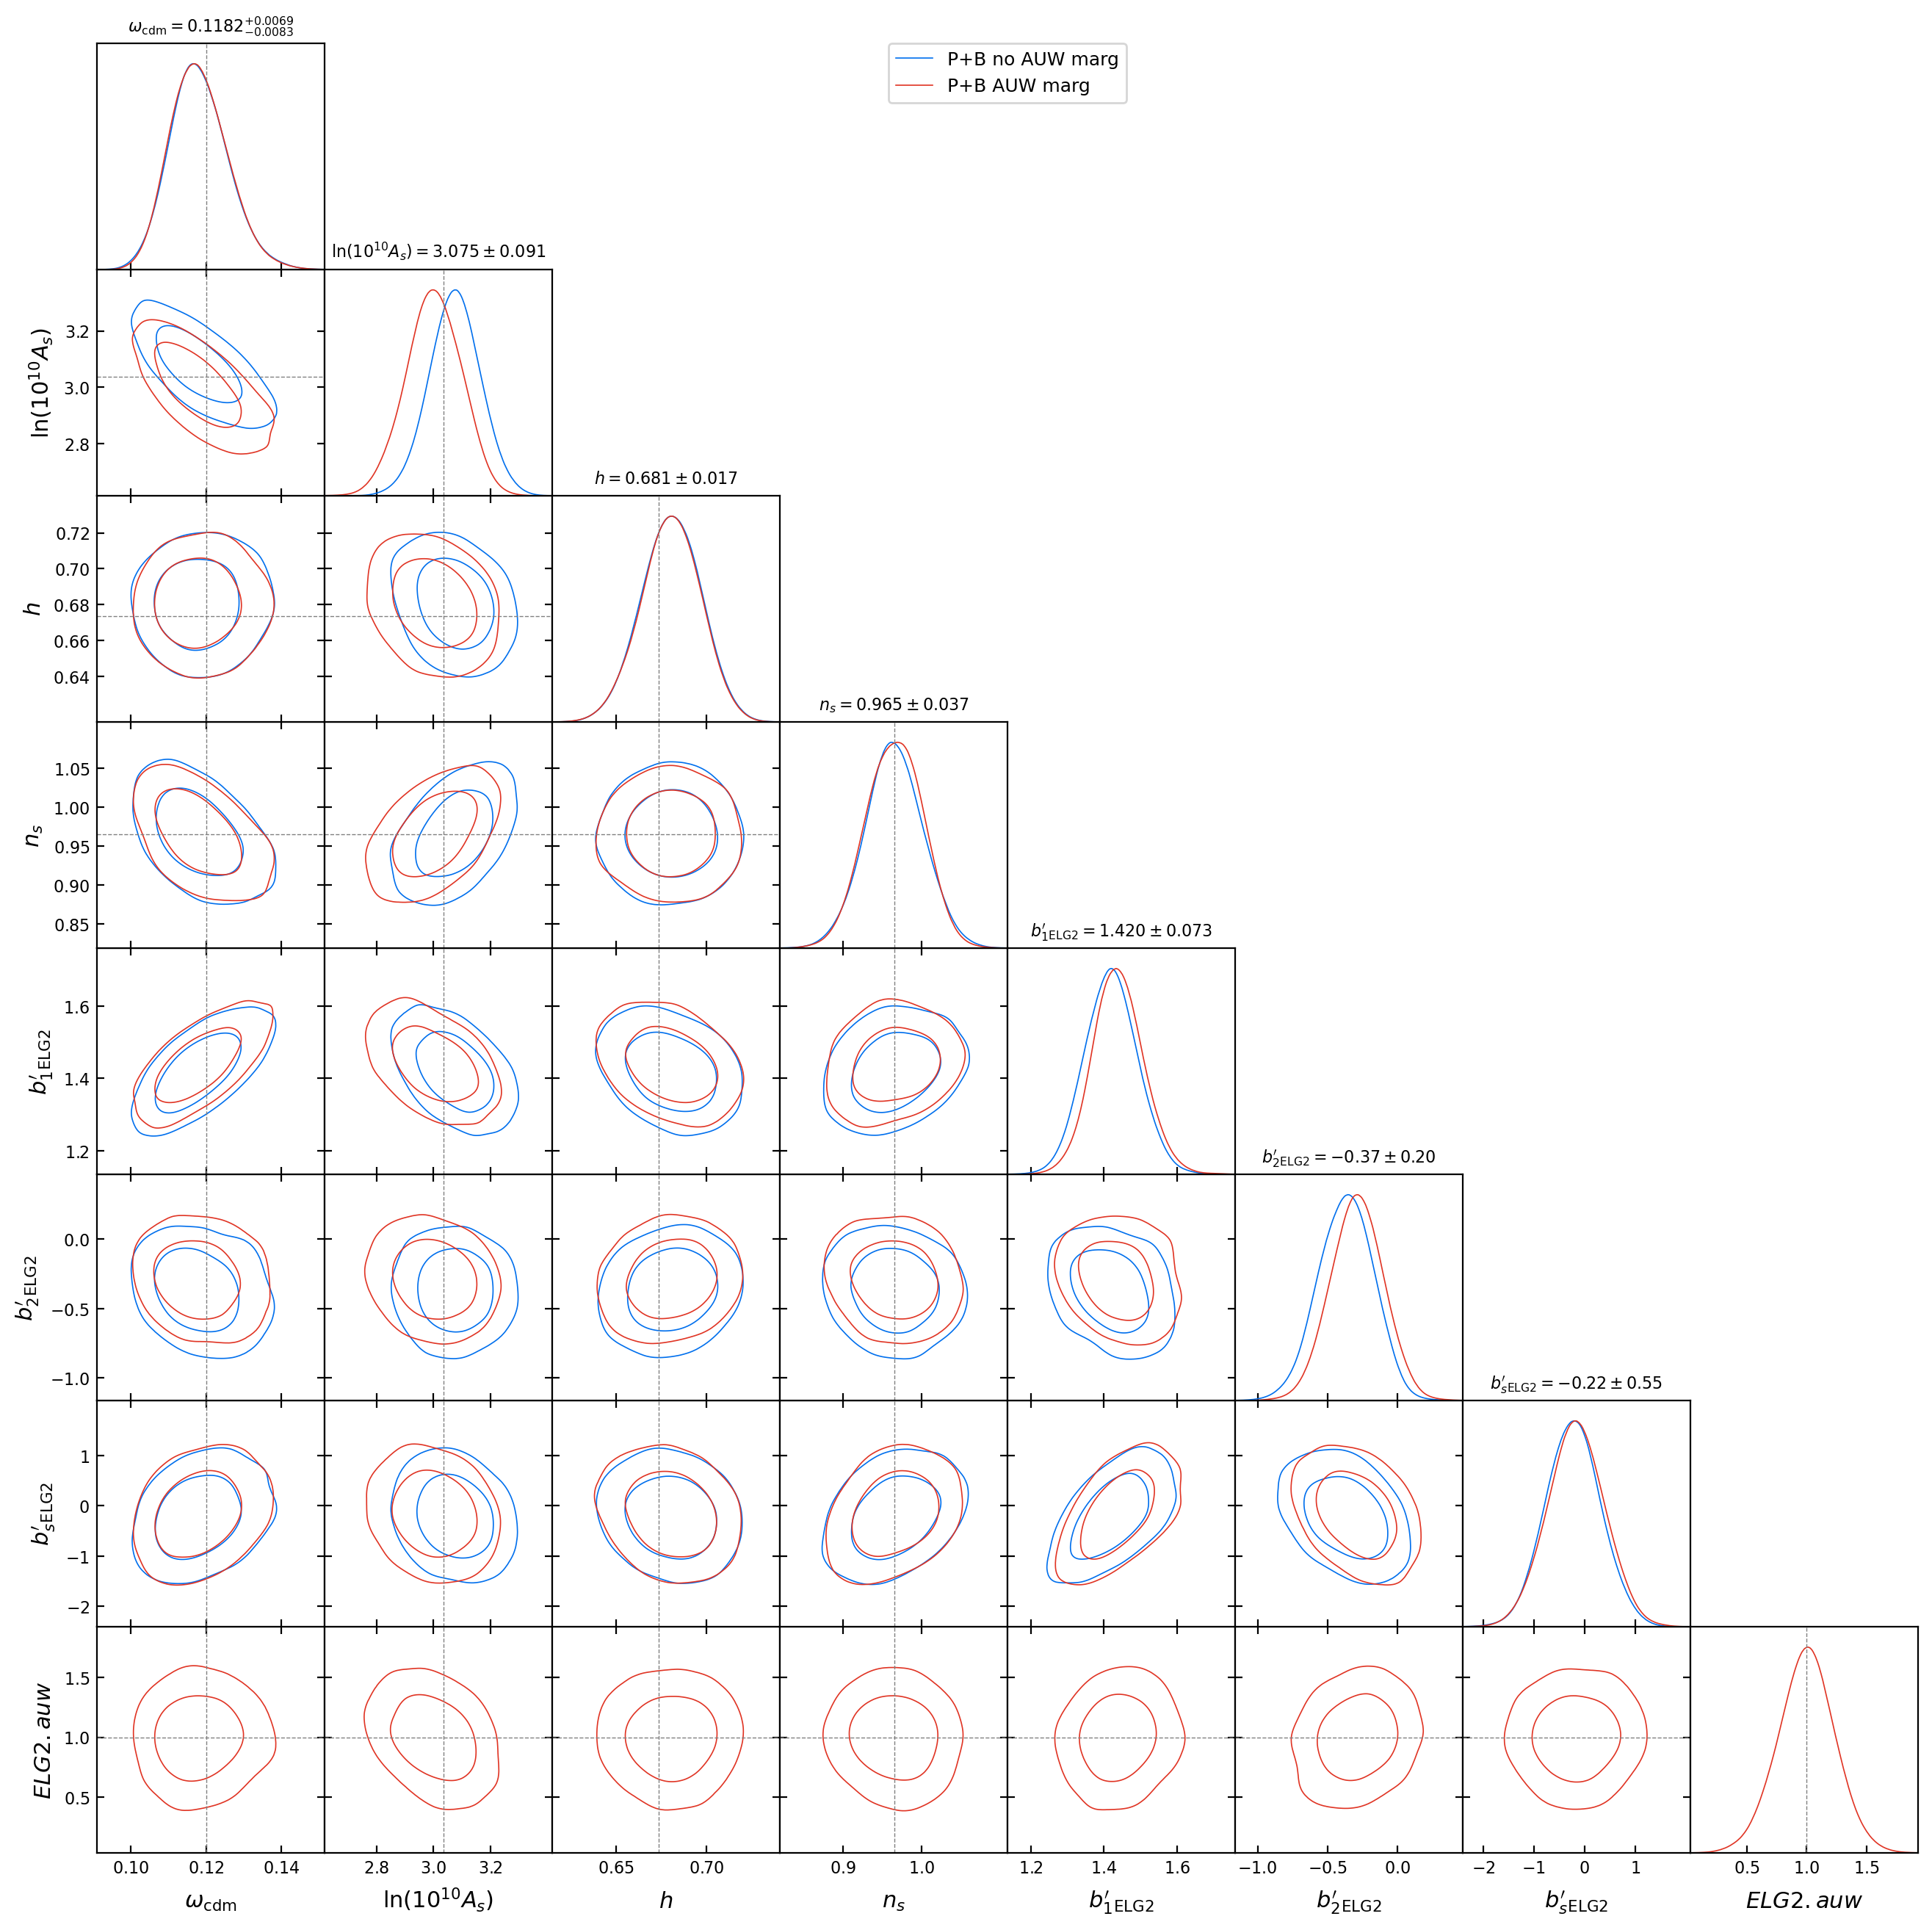

In [22]:
dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates/abacus-hf-dr2-v2-altmtl/')
samples, legends = [], []
#samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-21e7c046/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
#legends.append('P no AUW marg')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2+ELG2-S3-1a5c1386/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('P+B no AUW marg')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-w-auw+ELG2-S3-w-auw-adac9cd6/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('P+B AUW marg')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [19]:
print(samples[0].to_stats(tablefmt='pretty'))
print(samples[1].to_stats(tablefmt='pretty'))

+------------+---------+---------+---------+---------+-----------------+-----------------+
|            | argmax  |  mean   | median  |   std   | quantile:1sigma | interval:1sigma |
+------------+---------+---------+---------+---------+-----------------+-----------------+
|     h      |  0.683  |  0.681  |  0.681  |  0.017  |  +0.017/-0.017  |  +0.017/-0.016  |
|  omega_b   | 0.02261 | 0.02239 | 0.02240 | 0.00055 | +5.5e-4/-5.5e-4 | +5.5e-4/-5.5e-4 |
| omega_cdm  | 0.1256  | 0.1182  | 0.1177  | 0.0078  | +0.0077/-0.0076 | +0.0070/-0.0082 |
|    logA    |  3.010  |  3.075  |  3.075  |  0.091  |  +0.090/-0.090  |  +0.091/-0.089  |
|    n_s     |  0.953  |  0.965  |  0.965  |  0.037  |  +0.037/-0.037  |  +0.037/-0.037  |
|  ELG2.b1   |  1.485  |  1.420  |  1.419  |  0.073  |  +0.072/-0.073  |  +0.073/-0.072  |
|  ELG2.b2   |  -0.12  |  -0.37  |  -0.36  |  0.20   |   +0.20/-0.20   |   +0.21/-0.18   |
|  ELG2.bs   |  -0.18  |  -0.22  |  -0.22  |  0.55   |   +0.55/-0.55   |   +0.52/-0.57   |

### Blinded data

In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2

dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates/data-dr2-v2/')
params_toplot = ['omega_cdm', 'logA', 'h', 'n_s']
params_marg = ['auw', 'amr', 'ric']

tracers = {
    'BGS1': ('cosmo-base_BGS1-S2+BGS1-S3-2fb311ea', 'cosmo-base_BGS1-S2-w-auw+BGS1-S3-w-auw-72771d01', 'cosmo-base_BGS1-S2-w-auw-amr-ric+BGS1-S3-w-auw-amr-ric-4315d631'),
    'LRG1': ('cosmo-base_LRG1-S2+LRG1-S3-ac3ae9bf', 'cosmo-base_LRG1-S2-w-auw+LRG1-S3-w-auw-04179051', 'cosmo-base_LRG1-S2-w-auw-amr-ric+LRG1-S3-w-auw-amr-ric-0c481c92'),
    'LRG2': ('cosmo-base_LRG2-S2+LRG2-S3-905fd838', 'cosmo-base_LRG2-S2-w-auw+LRG2-S3-w-auw-2cb22a83', 'cosmo-base_LRG2-S2-w-auw-amr-ric+LRG2-S3-w-auw-amr-ric-dde3984e'),
    'LRG3': ('cosmo-base_LRG3-S2+LRG3-S3-2955a2f5', 'cosmo-base_LRG3-S2-w-auw+LRG3-S3-w-auw-6f8bf13a', 'cosmo-base_LRG3-S2-w-auw-amr-ric+LRG3-S3-w-auw-amr-ric-b80a5ec5'),
    'ELG2': ('cosmo-base_ELG2-S2+ELG2-S3-4464f84d', 'cosmo-base_ELG2-S2-w-auw+ELG2-S3-w-auw-d95296ad', 'cosmo-base_ELG2-S2-w-auw-amr-ric+ELG2-S3-w-auw-amr-ric-01e8f533'),
    'QSO1': ('cosmo-base_QSO1-S2+QSO1-S3-037fdae0', 'cosmo-base_QSO1-S2-w-auw+QSO1-S3-w-auw-eb57d836', 'cosmo-base_QSO1-S2-w-auw-amr-ric+QSO1-S3-w-auw-amr-ric-9176fb23'),  # fix if needed
}

stats = {'base': defaultdict(list), 'AUW, AMR, RIC': defaultdict(list)}

tracer_names, params_labels = [], {}

for tracer, (basename, basename_auw, basename_auw_amr_ric) in tracers.items():
    tracer_names.append(tracer)
    samples = read_samples([dirname / basename / f'samples_{i + 1}.h5' for i in range(4)], burnin=0.3, thin=10)
    samples_auw = read_samples([dirname / basename_auw / f'samples_{i + 1}.h5' for i in range(4)], burnin=0.3, thin=10)
    samples_auw_amr_ric = read_samples([dirname / basename_auw_amr_ric / f'samples_{i + 1}.h5' for i in range(4)], burnin=0.3, thin=10)

    # ----- triangle plot -----
    for param in params_marg: truth[tracer + '.' + param] = 1.
    plotting.plot_triangle([samples, samples_auw, samples_auw_amr_ric], params=params_toplot + params_marg, title_limit=1, markers=truth, legend_labels=['P+B no AUW marg', 'P+B AUW marg'])
    fig = plt.gcf()
    fig.suptitle(tracer)
    fig.savefig(plot_dir / f'triangle_{tracer}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    for param in params_toplot:
        params_labels[param] = samples_auw[param].latex(inline=True)
        stats['base'][param].append((samples.mean(param), samples.std(param)))
        stats['AUW'][param].append((samples_auw.mean(param), samples_auw.std(param)))
        stats['AUW, AMR, RIC'][param].append((samples_auw_amr_ric.mean(param), samples_auw_amr_ric.std(param)))

# ----- stack plot -----
fig, axes = plt.subplots(len(params_toplot), 1, figsize=(7, 2.8 * len(params_toplot)), sharex=True)
x = np.arange(len(tracer_names))
dx = 0.12

for ax, param in zip(axes, params_toplot):

    # no AUW
    for key in stats:
        means = np.array([m for m, s in stats[key][param]])
        stds  = np.array([s for m, s in stats[key][param]])
        ax.errorbar(x - dx, means, yerr=stds, fmt='o', capsize=3, label=f'P+B {key}')

    # weighted mean
    w = 1.0 / stds**2
    mean = np.sum(w * means) / np.sum(w)
    mean_err = np.sqrt(1.0 / np.sum(w))

    # horizontal line
    ax.axhline(mean, color='C1', ls='--', lw=1.5)

    # chi2 consistency
    chi2_val = np.sum((means - mean)**2 / stds**2)
    ndof = len(means) - 1
    pval = chi2.sf(chi2_val, ndof)

    print(f"{param:10s}: mean = {mean:.6g} ± {mean_err:.2g}, "
          f"chi2 = {chi2_val:.2f}/{ndof}, p = {pval:.3f}")

    ax.set_title(rf"{params_labels[param]}: $\chi^2/{ndof}={chi2_val:.1f}/{ndof}$, $p={pval:.3f}$")
    ax.set_ylabel(params_labels[param])
    ax.grid(alpha=0.3)

axes[0].legend(frameon=False)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(tracer_names)

fig = plt.gcf()
fig.savefig(plot_dir / f'stacked_templates.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.tight_layout()
plt.show()

### ELG catalog version with NN weights

Removed no burn in
Removed no burn in


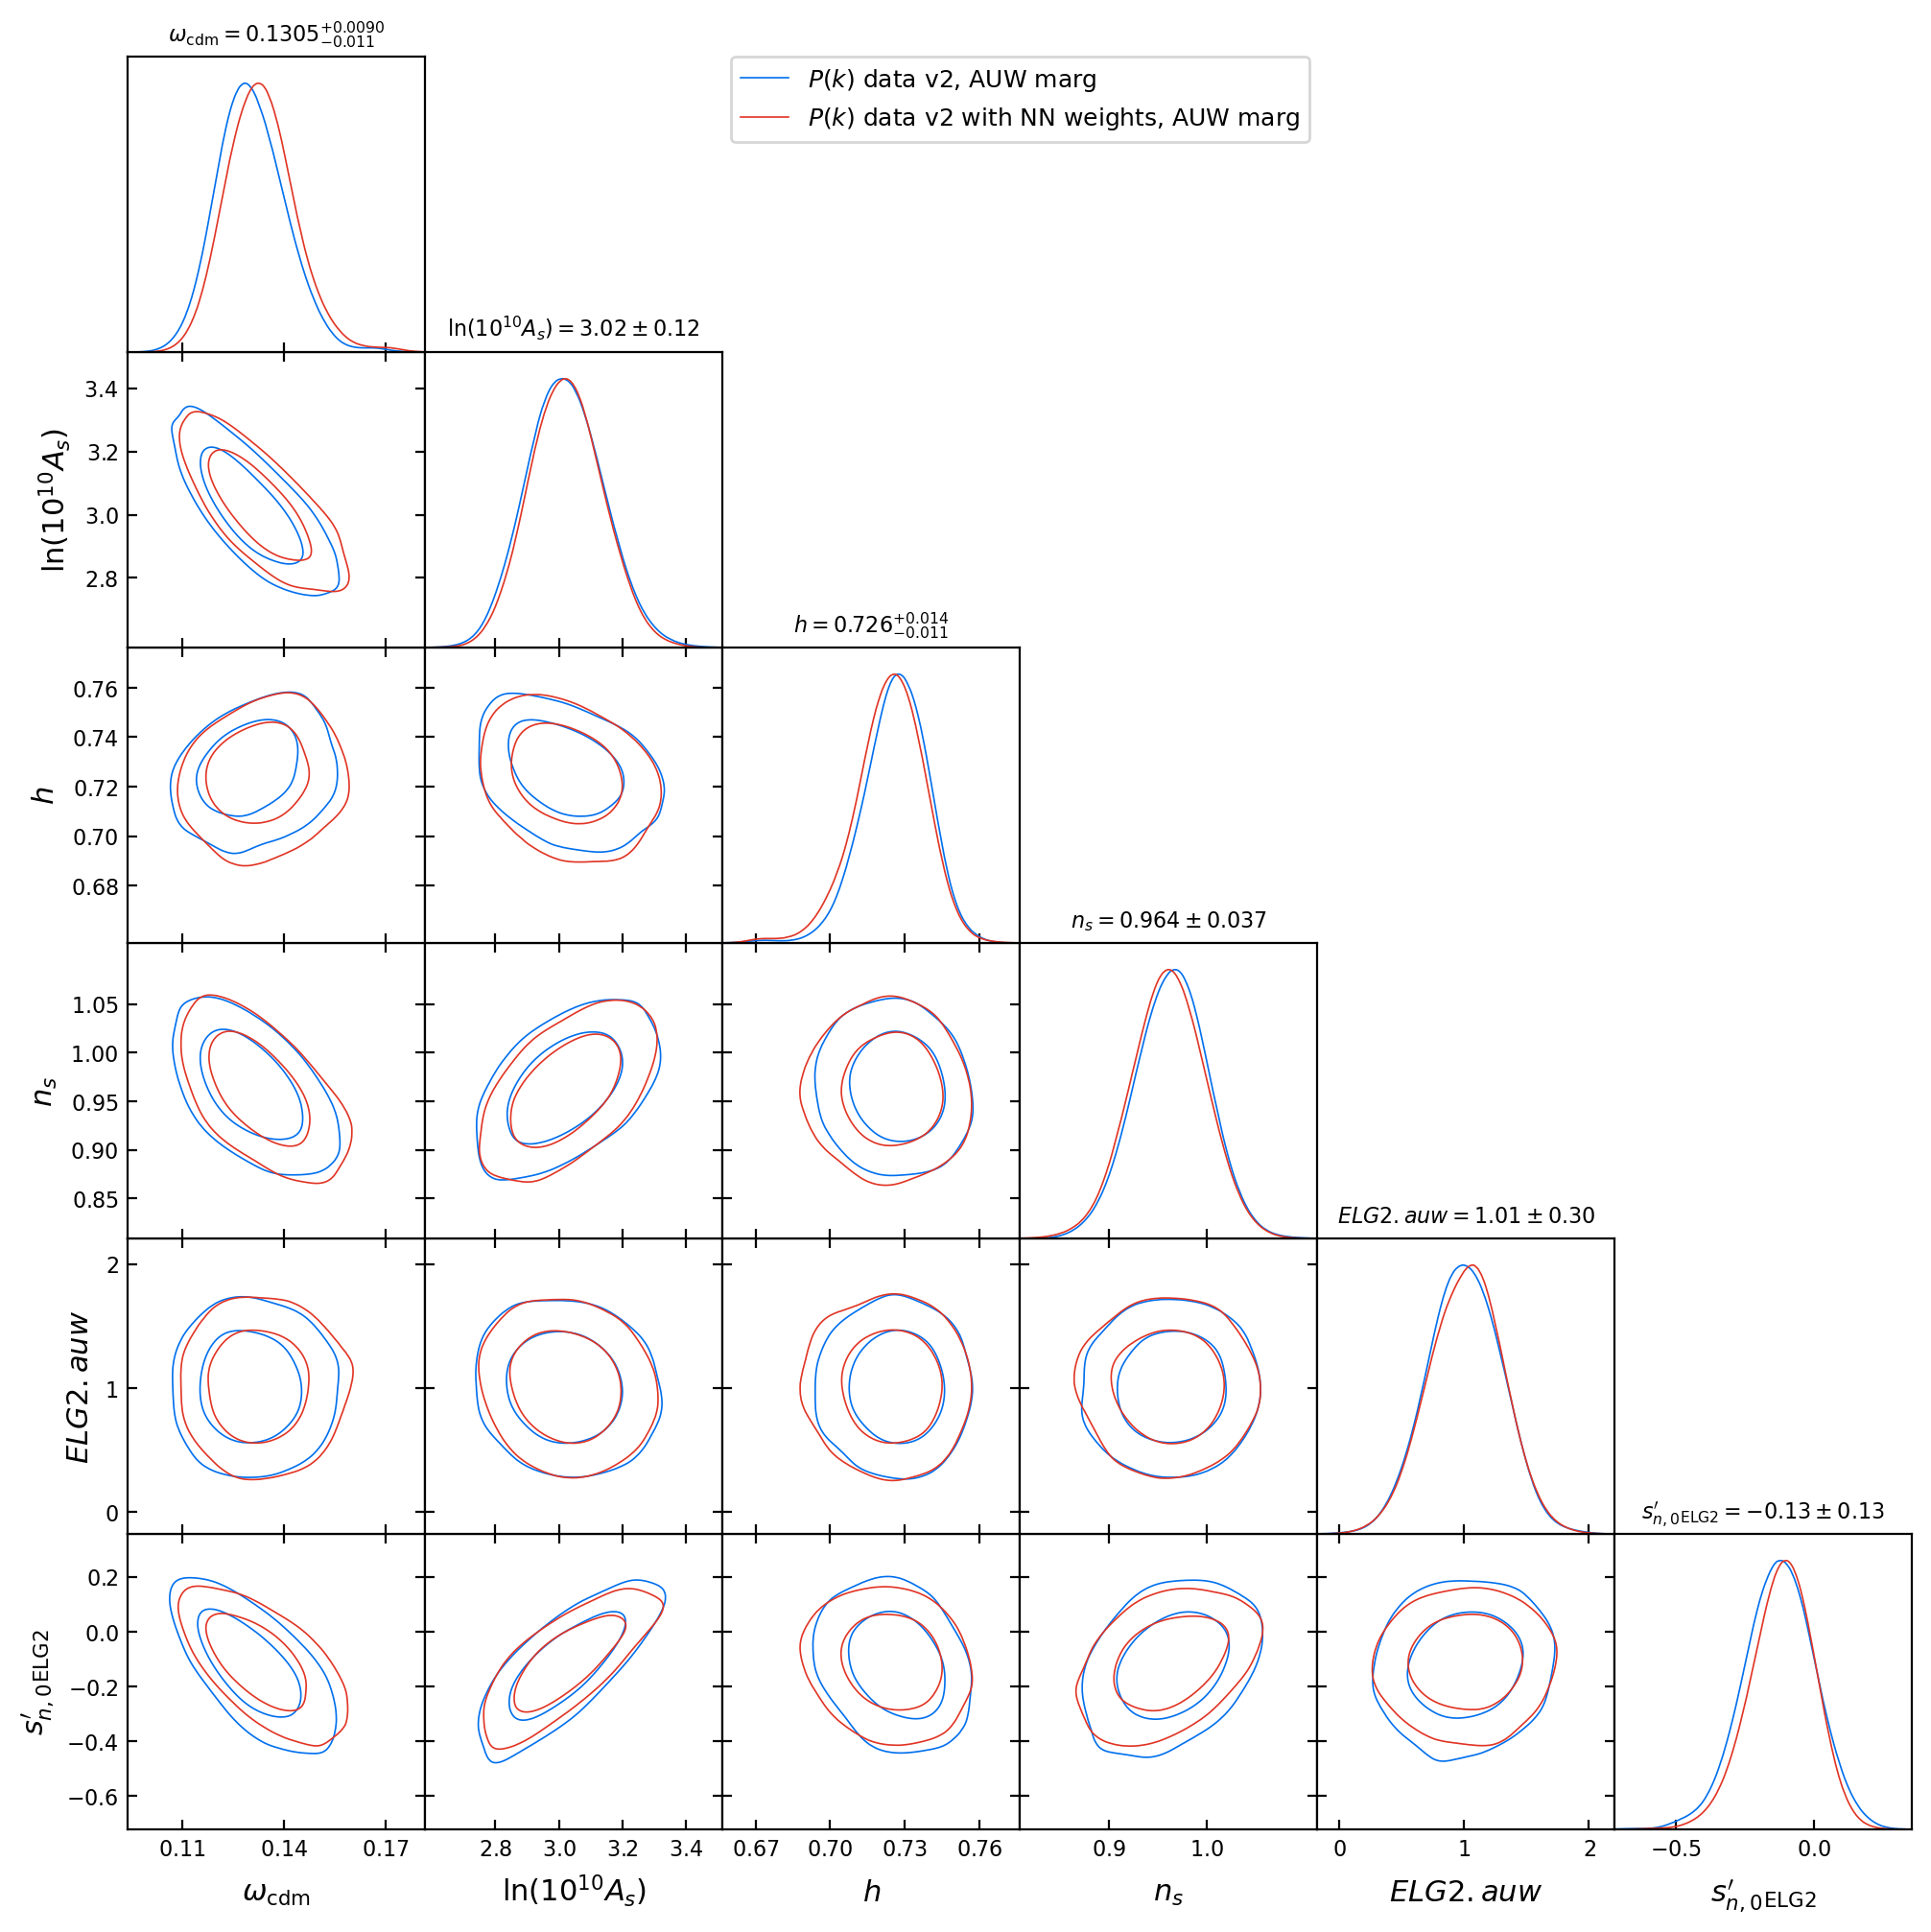

In [4]:
dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates')
params_toplot = ['omega_cdm', 'logA', 'h', 'n_s', 'ELG2.auw', 'ELG2.sn0'] #, 'ELG2.b1', 'ELG2.b2', 'ELG2.bs', 'ELG2.c1', 'ELG2.snb0'] #['ELG2.alpha0', 'ELG2.alpha2', 'ELG2.alpha4', 'ELG2.sn0', 'ELG2.sn2', 'ELG2.sn4', 'ELG2.auw']

samples, legends = [], []
samples.append(read_samples([dirname / 'data-dr2-v2' / f'cosmo-base_ELG2-S2-w-auw-50e21258/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2, AUW marg')
samples.append(read_samples([dirname / 'data-dr2-test-maskedfraczpNN' / f'cosmo-base_ELG2-S2-w-auw-403adc77/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2 with NN weights, AUW marg')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle_data_nn.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

Removed no burn in
Removed no burn in


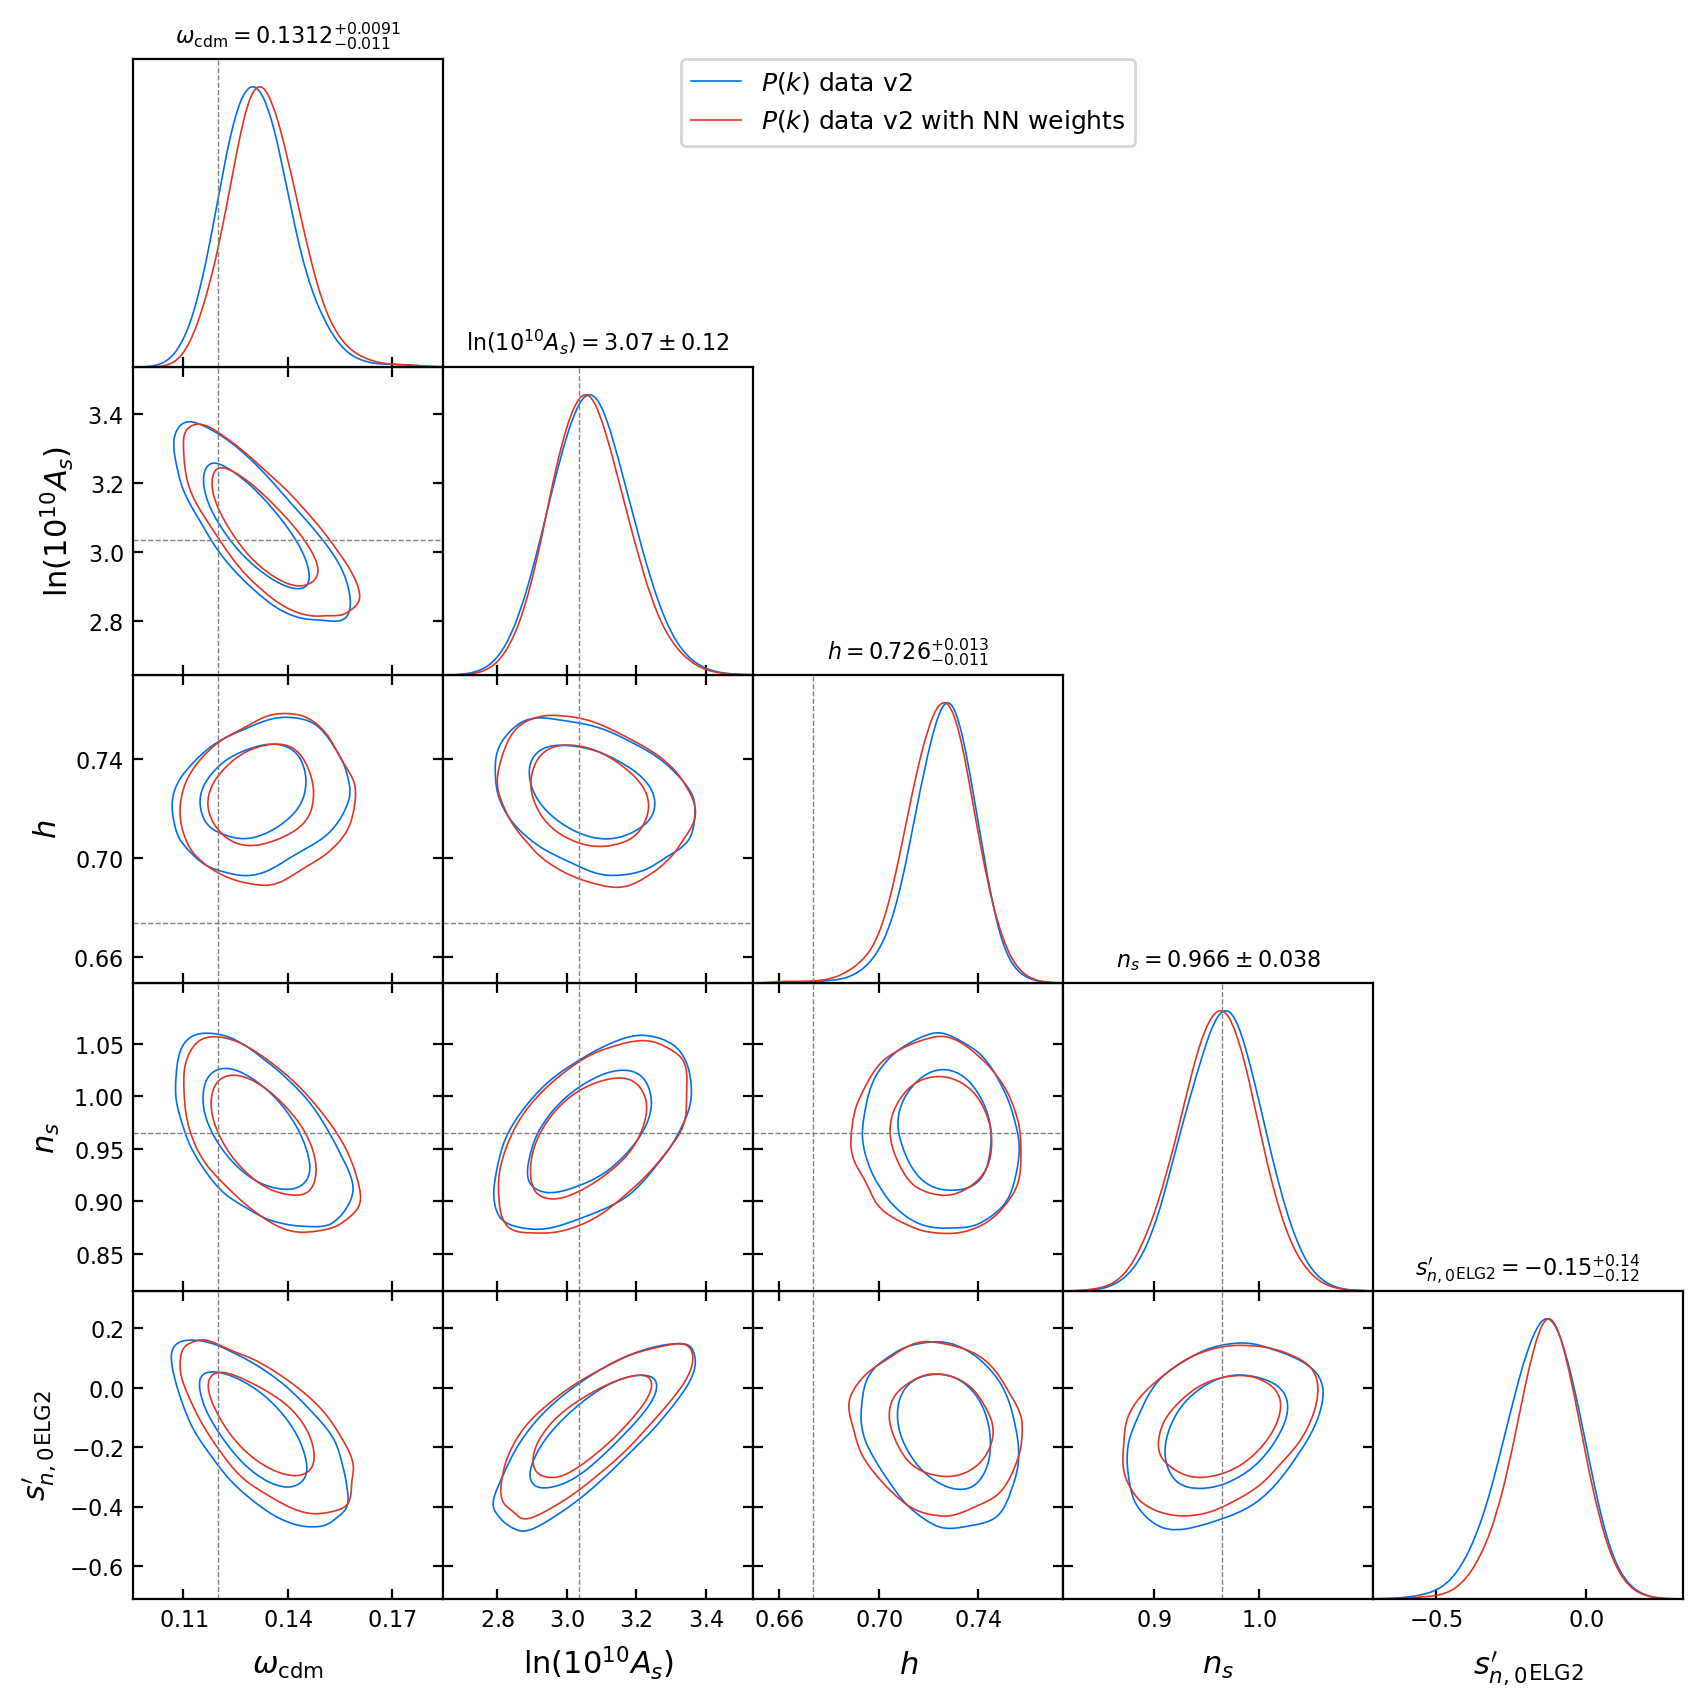

In [5]:
samples, legends = [], []
samples.append(read_samples([dirname / 'data-dr2-v2' / f'cosmo-base_ELG2-S2-ff1998b4/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2')
samples.append(read_samples([dirname / 'data-dr2-test-maskedfraczpNN' / f'cosmo-base_ELG2-S2-2f89d096/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2 with NN weights')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()